<a href="https://colab.research.google.com/github/Nandhinimh/DEEPFAKE_DETECTION/blob/main/STATISTICAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
import zipfile, os
uploaded = files.upload()

Saving archive.zip to archive.zip


In [4]:
# Extract uploaded file
for fn in uploaded.keys():
    zip_name = fn

dataset_dir = "/content/deepfake_dataset"
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)

print("Dataset extracted successfully at:", dataset_dir)
print("Folders:", os.listdir(dataset_dir))

Dataset extracted successfully at: /content/deepfake_dataset
Folders: ['real_and_fake_face', 'real_and_fake_face_detection']


In [5]:
#Import Libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report

In [6]:
#Extract Statistical Features from Images
def extract_stats_features(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (128,128))

    # Compute basic statistical descriptors
    mean = np.mean(img)
    std = np.std(img)
    var = np.var(img)
    skew = np.mean((img - mean)**3) / (std**3 + 1e-8)
    kurt = np.mean((img - mean)**4) / (std**4 + 1e-8)
    hist = cv2.calcHist([img], [0], None, [16], [0,256]).flatten()
    hist = hist / np.sum(hist)

    features = np.hstack([mean, std, var, skew, kurt, hist])
    return features

X, y = [], []
classes = ['real_and_fake_face/training_real', 'real_and_fake_face/training_fake']
for label, cls in enumerate(classes):
    folder = os.path.join(dataset_dir, cls)
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        feat = extract_stats_features(path)
        if feat is not None:
            X.append(feat)
            y.append(label)

X = np.array(X)
y = np.array(y)
print(f"Extracted statistical features: {X.shape}")

Extracted statistical features: (2041, 21)


In [7]:
#Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [8]:
# Train Statistical Models
print("\nTraining statistical models...")

lr = LogisticRegression(max_iter=500)
nb = GaussianNB()
lda = LinearDiscriminantAnalysis()

lr.fit(X_train, y_train)
nb.fit(X_train, y_train)
lda.fit(X_train, y_train)


Training statistical models...


LinearDiscriminantAnalysis()

In [9]:
#Evaluate Models
y_pred_lr = lr.predict(X_test)
y_pred_nb = nb.predict(X_test)
y_pred_lda = lda.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_nb = accuracy_score(y_test, y_pred_nb)
acc_lda = accuracy_score(y_test, y_pred_lda)

print("\nModel Performance Summary:")
print(f"Logistic Regression Accuracy: {acc_lr*100:.2f}%")
print(f"Naive Bayes Accuracy:          {acc_nb*100:.2f}%")
print(f"LDA Accuracy:                  {acc_lda*100:.2f}%")

print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("Naive Bayes Report:\n", classification_report(y_test, y_pred_nb))
print("LDA Report:\n", classification_report(y_test, y_pred_lda))


Model Performance Summary:
Logistic Regression Accuracy: 51.10%
Naive Bayes Accuracy:          52.32%
LDA Accuracy:                  50.37%

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.53      0.76      0.62       218
           1       0.45      0.23      0.31       191

    accuracy                           0.51       409
   macro avg       0.49      0.49      0.46       409
weighted avg       0.49      0.51      0.47       409

Naive Bayes Report:
               precision    recall  f1-score   support

           0       0.56      0.49      0.52       218
           1       0.49      0.56      0.52       191

    accuracy                           0.52       409
   macro avg       0.53      0.53      0.52       409
weighted avg       0.53      0.52      0.52       409

LDA Report:
               precision    recall  f1-score   support

           0       0.52      0.76      0.62       218
           1       0.44      0.2

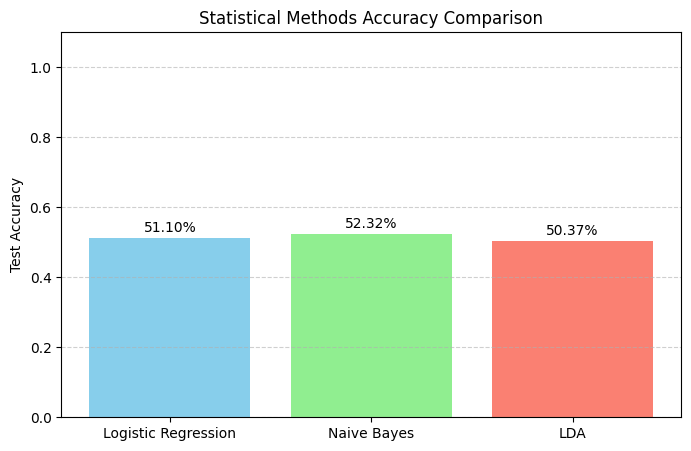

In [10]:
# Visualize Comparison
models = ['Logistic Regression', 'Naive Bayes', 'LDA']
accuracies = [acc_lr, acc_nb, acc_lda]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=['skyblue','lightgreen','salmon'])
plt.title("Statistical Methods Accuracy Comparison")
plt.ylabel("Test Accuracy")

for bar, acc in zip(bars, accuracies):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{acc*100:.2f}%", ha='center', va='bottom')

plt.ylim(0,1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [11]:
#Print Best Model
best_model = models[np.argmax(accuracies)]
print(f"\n Best Performing Statistical Model: {best_model}")


 Best Performing Statistical Model: Naive Bayes
